In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('C:/Users/viryu/Downloads/Top Mentors/Gen AI Session 1/Assignment/gas_turbines.csv')
df.head(5)
df.shape
df.isnull().sum()
df.describe().T

,count,mean,std,min,25%,50%,75%,max
AT,15039.0,17.764381,7.574323,0.522300,11.408000,18.1860,23.8625,34.9290
AP,15039.0,1013.199240,6.410760,985.850000,1008.900000,1012.8000,1016.9000,1034.2000
AH,15039.0,79.124174,13.793439,30.344000,69.750000,82.2660,90.0435,100.2000
AFDP,15039.0,4.200294,0.760197,2.087400,3.723900,4.1862,4.5509,7.6106
GTEP,15039.0,25.419061,4.173916,17.878000,23.294000,25.0820,27.1840,37.4020
TIT,15039.0,1083.798770,16.527806,1000.800000,1079.600000,1088.7000,1096.0000,1100.8000
TAT,15039.0,545.396183,7.866803,512.450000,542.170000,549.8900,550.0600,550.6100
TEY,15039.0,134.188464,15.829717,100.170000,127.985000,133.7800,140.8950,174.6100
CDP,15039.0,12.102353,1.103196,9.904400,11.622000,12.0250,12.5780,15.0810
CO,15039.0,1.972499,2.222206,0.000388,0.858055,1.3902,2.1604,44.1030


In [3]:
df.head(5)

,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX
0,6.8594,1007.9,96.799,3.5000,19.663,1059.2,550.00,114.70,10.605,3.1547,82.722
1,6.7850,1008.4,97.118,3.4998,19.728,1059.3,550.00,114.72,10.598,3.2363,82.776
2,6.8977,1008.8,95.939,3.4824,19.779,1059.4,549.87,114.71,10.601,3.2012,82.468
3,7.0569,1009.2,95.249,3.4805,19.792,1059.6,549.99,114.72,10.606,3.1923,82.670
4,7.3978,1009.7,95.150,3.4976,19.765,1059.7,549.98,114.72,10.612,3.2484,82.311


In [4]:
X = df[['AT','AP','AH']]
y = df['TEY']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size =0.20,random_state=42)

print(" X train shape", X_train.shape, "|",  "X test shape", X_test.shape)

 X train shape (12031, 3) | X test shape (3008, 3)


In [5]:
scale = StandardScaler()
X_scaled_train = scale.fit_transform(X_train)
X_scaled_test = scale.transform(X_test)

In [6]:
model = Sequential()

model.add(Dense(128,activation='relu', input_shape = (X_train.shape[1],)))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss = 'mse',
    metrics=['mae'])

history = model.fit(X_train,y_train,
                    epochs=50,
                    batch_size = 32,
                    validation_split=.20,
                    verbose=1)



Epoch 1/50
301/301 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 339.4735 - mae: 13.5472 - val_loss: 263.6810 - val_mae: 12.8489
Epoch 2/50
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 258.4474 - mae: 12.5076 - val_loss: 263.6217 - val_mae: 13.1414
Epoch 3/50
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 243.6158 - mae: 12.0935 - val_loss: 227.5837 - val_mae: 11.4649
Epoch 4/50
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 242.1149 - mae: 12.2620 - val_loss: 229.5196 - val_mae: 11.8345
Epoch 5/50
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 234.8957 - mae: 12.0780 - val_loss: 220.0292 - val_mae: 11.5271
Epoch 6/50
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 236.0244 - mae: 12.1925 - val_loss: 221.8266 - val_mae: 11.6293
Epoch 7/50
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 236.4712 - mae: 12.2286 - val_loss: 223.6859 - val_mae: 11.7348
Epoch 8/50
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 236.3926 - mae: 12.2665 - val_loss: 235.1492 - val_mae: 12.1588
Epoch 9/

In [9]:
loss, mae = model.evaluate(X_test, y_test)
print("Test Loss (MSE)", loss,       '|',  "Test Erroe(MAE)", mae) 

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 232.9938 - mae: 12.2312
Test Loss (MSE) 232.99378967285156 | Test Erroe(MAE) 12.23124885559082


In [10]:
y_pred = model.predict(X_test)

for i in range(5):
    print("Actual",y_test.iloc[i], "Predict",y_pred[i][0])   

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Actual 134.46 Predict 133.53142
Actual 111.88 Predict 131.12875
Actual 133.72 Predict 133.10612
Actual 133.79 Predict 134.56711
Actual 110.77 Predict 130.28015


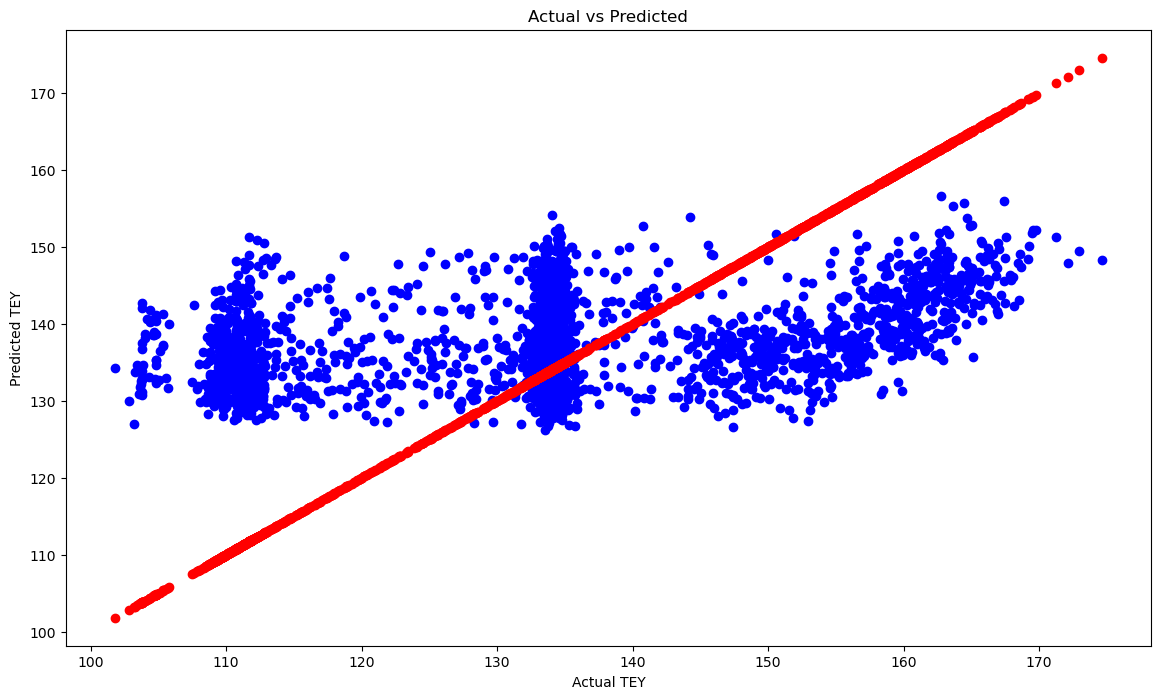

In [25]:
plt.figure(figsize = (14,8))
plt.scatter(y_test, y_pred, color='blue', label='Predicted')
plt.scatter(y_test, y_test, color='red', label='Actual')

plt.xlabel("Actual TEY")
plt.ylabel("Predicted TEY")
plt.title("Actual vs Predicted")
plt.show()

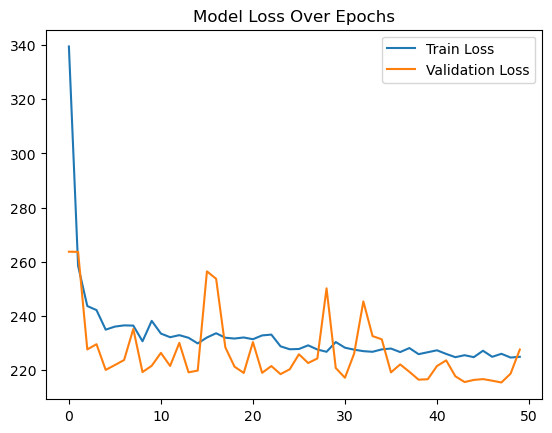

In [27]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.legend()
plt.title("Model Loss Over Epochs")
plt.show()

### Interpretation
Both lines going down → good

Validation going up → overfitting 

# Model Description:

A neural network model was built using Keras to predict Turbine Energy Yield (TEY) using ambient variables (AT, AP, AH). The data was split into training and testing sets and scaled using StandardScaler.

# Model Architecture:

The model consists of three hidden layers with 128, 64 and 32 neurons respectively, using ReLU activation, and an output layer with one neuron for regression.

# Results:

The model achieved a Mean Absolute Error (MAE) of 12.2312 , indicating that predictions are on average 130–134 range units away from actual TEY values. The loss curves show stable convergence.

# Conclusion:

The model demonstrates that ambient variables have a measurable impact on turbine energy yield, though performance may improve with additional features.